In [19]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from scipy.stats import kendalltau
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.metrics import roc_curve, auc
import joblib

In [ ]:
def norm_name(x):
    """'Отбрасывает дробную часть числа: 
    41.0' → '41'
    """
    s = str(x)
    if s.endswith('.0') and s[:-2].lstrip('-').isdigit():
        return s[:-2]
    return s


features_df = pd.read_csv('../data/interim/building_features_402-32d-b2.csv')

features_df['building_name'] = features_df['building_name'].apply(norm_name)

features_df.set_index('building_name', inplace=True)

sessions = ['coating_deterioration', 
            'masonry_degradation',
            'moisture_bio_damage', 
            'vandalism'
            ]

FEATURE_COLS = {session: ['mean', 
                          'max', 
                          'prevalence', 
                          'std',
                          'q75', 
                          'skewness', 
                          'concentration', 
                          'severity_coverage'
                        ]
                for session in sessions}

n_folds = 5

In [6]:
# Вспомогательная функция
def extract_pairs(df, feature_cols, scaler):
    '''
    функция берет таблицу с результатами сравнений зданий
    и создает пары признаков (разницы между зданиями) и соответствующие им метки    
    '''
    # Списки для хранения данных
    X, y = [], []
    # Проходимся по каждой строке в нашей таблице сравнений
    for _, row in df.iterrows():
        # Извлекаем имена двух сравниваемых зданий и информацию о победителе
        img_a, img_b, winner = str(row['image_a']), str(row['image_b']), str(row['winner'])
        # Игнорируем посторонии символы
        if winner not in ['0', '1']:
            continue
        # Нормализуем признаки
        vec_a = scaler.transform(features_df.loc[img_a, feature_cols].values.reshape(1,-1))[0]
        vec_b = scaler.transform(features_df.loc[img_b, feature_cols].values.reshape(1,-1))[0]
        # Определяем метку для пары: 0, если "a" хуже, иначе 1.
        label = 1 if winner == '0' else 0
        # Оригинальная пара
        X.append(vec_a - vec_b)
        y.append(label)
        # Симметричная пара
        X.append(vec_b - vec_a)
        y.append(1 - label)
    return np.array(X, dtype=np.float32), np.array(y)


# Обучение на кросс-валидации
lr_models_final  = {}  # финальные модели для инференса
lr_scalers_final = {}  # нормализаторы
all_taus, all_accs, roc_data = {}, {}, {}

for session in sessions:
    pairs_file = f'../data/input/ranking-dataset/ranking_pairs_{session}.csv'

    # Загружаем и сразу фильтруем ничьи
    pairs_df = (pd.read_csv(pairs_file)
                .assign(winner=lambda d: d['winner'].astype(str),
                        image_a=lambda d: d['image_a'].apply(norm_name),
                        image_b=lambda d: d['image_b'].apply(norm_name))
                .query("winner in ['0', '1']")
                .reset_index(drop=True))
    # Определяем, какие колонки с признаками нам нужны для текущей сессии
    feature_cols = [f"{session}_{f}" for f in FEATURE_COLS[session]]
    
    # Кросс-валидация
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    # Списки для хранения метрик для каждого фолда
    fold_taus, fold_accs = [], []

    # Списки для сбора out-of-fold предсказаний
    oof_y, oof_proba = [], []
    # Проходимся по каждому фолду
    for train_idx, val_idx in kf.split(pairs_df):
        train_fold = pairs_df.iloc[train_idx]
        val_fold   = pairs_df.iloc[val_idx]

        # Scaler обучаем только на train-зданиях текущего фолда
        train_buildings = set(train_fold['image_a'].tolist() + train_fold['image_b'].tolist())
        train_mask = features_df.index.isin(train_buildings)
        fold_scaler = StandardScaler()
        fold_scaler.fit(features_df.loc[train_mask, feature_cols].values)
        # используем нашу вспомогательную функцию extract_pairs
        X_train, y_train = extract_pairs(train_fold, feature_cols, fold_scaler)
        X_val,   y_val   = extract_pairs(val_fold,   feature_cols, fold_scaler)
        # Обучаем модель
        lr = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
        lr.fit(X_train, y_train)

        val_proba = lr.predict_proba(X_val)[:, 1]
        acc = accuracy_score(y_val, (val_proba > 0.5).astype(int))
        tau, _ = kendalltau(y_val, val_proba)
        fold_taus.append(0.0 if np.isnan(tau) else tau)
        fold_accs.append(acc)
        # Собираем out-of-fold метки и предсказанные вероятности
        oof_y.append(y_val)
        oof_proba.append(val_proba)


    # Финальная модель на всех парах
    all_taus[session] = fold_taus
    all_accs[session] = fold_accs
    roc_data[session] = (np.concatenate(oof_y), np.concatenate(oof_proba))


    all_buildings = set(pairs_df['image_a'].tolist() + pairs_df['image_b'].tolist())
    final_scaler = StandardScaler()

    # скейлер на всей выборке
    final_scaler.fit(features_df[feature_cols].values)
    lr_scalers_final[session] = final_scaler

    X_all, y_all = extract_pairs(pairs_df, feature_cols, final_scaler)  # исправлено: было FEATURE_COLS
    final_lr = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
    final_lr.fit(X_all, y_all)
    lr_models_final[session] = final_lr

    # Результаты
    mean_tau = np.mean(fold_taus)
    std_tau  = np.std(fold_taus)
    per_fold = '  '.join([f'{t:.2f}' for t in fold_taus])

    print(f'{session.upper()}')
    print(f'   CV Tau:   {mean_tau:.3f} по фолдам: [{per_fold}]')
    print(f'   Accuracy: {np.mean(fold_accs):.3f}')
    print(f'   Веса финальной модели: {final_lr.coef_[0].round(3)}')
    print(f'   Признаки: {feature_cols}\n')


COATING_DETERIORATION
   CV Tau:   0.546 по фолдам: [0.56  0.56  0.49  0.49  0.63]
   Accuracy: 0.791
   Веса финальной модели: [ 0.615  0.488  0.181  0.253  0.484 -0.058  0.249  0.378]
   Признаки: ['coating_deterioration_mean', 'coating_deterioration_max', 'coating_deterioration_prevalence', 'coating_deterioration_std', 'coating_deterioration_q75', 'coating_deterioration_skewness', 'coating_deterioration_concentration', 'coating_deterioration_severity_coverage']

MASONRY_DEGRADATION
   CV Tau:   0.533 по фолдам: [0.63  0.53  0.42  0.64  0.44]
   Accuracy: 0.788
   Веса финальной модели: [ 0.211  0.583  0.216  0.378 -0.225 -0.677  0.37  -0.345]
   Признаки: ['masonry_degradation_mean', 'masonry_degradation_max', 'masonry_degradation_prevalence', 'masonry_degradation_std', 'masonry_degradation_q75', 'masonry_degradation_skewness', 'masonry_degradation_concentration', 'masonry_degradation_severity_coverage']

MOISTURE_BIO_DAMAGE
   CV Tau:   0.573 по фолдам: [0.53  0.55  0.67  0.53  0.5

In [ ]:
# Сохранение моделей и скейлеров
joblib.dump(lr_models_final, '../models/lr_models.pkl')
joblib.dump(lr_scalers_final, '../models/lr_scalers.pkl')

['../models/lr_scalers.pkl']

## Отрисовка графиков

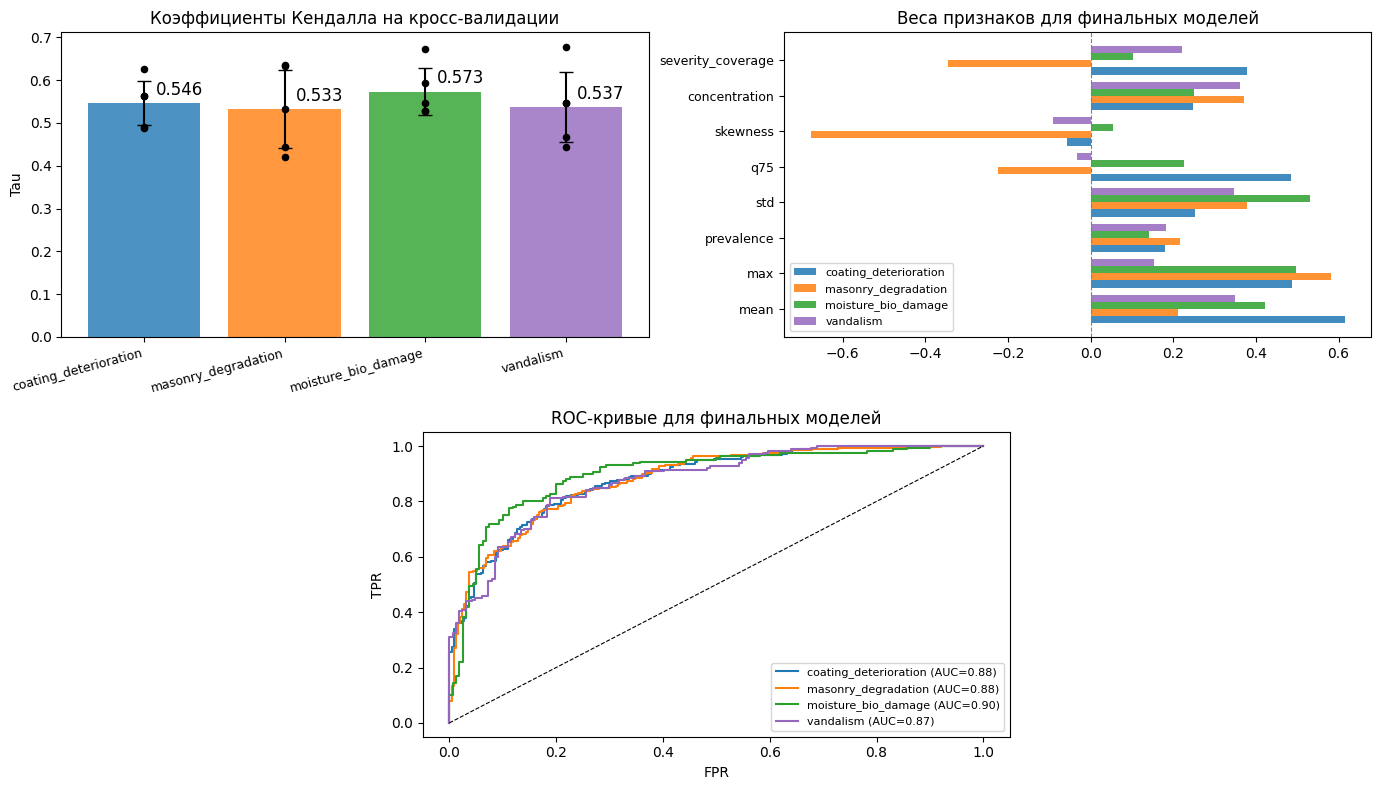

In [10]:
fig = plt.figure(figsize=(14, 8))

gs = gridspec.GridSpec(2, 4)

ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[1, 1:3])

sessions = list(all_taus.keys())
colors_lr = plt.cm.tab10(np.linspace(0, 0.4, len(sessions)))

# Tau и Accuracy по сессиям
ax = ax1
x = np.arange(len(sessions))
means = [np.mean(all_taus[s]) for s in sessions]
stds  = [np.std(all_taus[s])  for s in sessions]
bars = ax.bar(
    x, means,
    yerr=stds,
    capsize=5,
    color=colors_lr,
    alpha=0.8
)

for bar, mean in zip(bars, means):
    ax.text(
        bar.get_x() + 0.6 * bar.get_width(),
        bar.get_height() + 0.01,
        f"{mean:.3f}",
        ha='left',
        va='bottom',
        fontsize=12
    )

for i, s in enumerate(sessions):
    ax.scatter([i]*len(all_taus[s]), all_taus[s], color='black', s=20, zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(sessions, rotation=15, ha='right', fontsize=9)
ax.set(title="Коэффициенты Кендалла на кросс-валидации", ylabel="Tau")
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')

# Коэффициенты финальных моделей
ax = ax2
bar_h = 0.8 / len(sessions)
for i, s in enumerate(sessions):
    coef = lr_models_final[s].coef_[0]
    feat = FEATURE_COLS[s]
    y_pos = np.arange(len(feat)) + i * bar_h - (len(sessions)-1) * bar_h / 2
    ax.barh(y_pos, coef, bar_h, label=s, color=colors_lr[i], alpha=0.85)
# берём признаки первой сессии как ось Y (если у всех одинаковые)
ax.set_yticks(np.arange(len(FEATURE_COLS[sessions[0]])))
ax.set_yticklabels(FEATURE_COLS[sessions[0]], fontsize=9)
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set(title="Веса признаков для финальных моделей")
ax.legend(fontsize=8)

# ROC-кривые
ax = ax3
for i, s in enumerate(sessions):
    y_true, proba = roc_data[s]
    fpr, tpr, _ = roc_curve(y_true, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{s} (AUC={roc_auc:.2f})", color=colors_lr[i])
ax.plot([0,1],[0,1], 'k--', linewidth=0.8)
ax.set(title="ROC-кривые для финальных моделей", xlabel="FPR", ylabel="TPR")
ax.legend(fontsize=8)

fig.tight_layout()
fig.subplots_adjust(wspace=0.6)
plt.savefig("logreg_results.pdf", bbox_inches="tight")
plt.show()


## Калибровка индексов и анализ результатов

In [11]:
classes = ['coating_deterioration', 'masonry_degradation',
           'moisture_bio_damage', 'vandalism']
class_labels = ['Повреждения\nотделки', 'Повреждения\nкладки',
                'Сырость/биопоражения', 'Вандализм']
class_colors = ['#4C9BE8', '#5CB85C', '#9B5DE5', '#F4A261']

features_csv = '../data/interim/building_features_402-32d-b2.csv'

# Путь для сохранения финальных индексов повреждения фасадов
scores_csv   = '../data/interim/facade_damage_scores_lr_4classes-b2.csv'

feature_cols = {s: [f'{s}_{f}' for f in ['mean', 'max', 'prevalence', 'std', 'q75',
'skewness', 
'concentration', 
'severity_coverage']
] for s in classes}

In [12]:
def norm_name(x):
    s = str(x)
    return s[:-2] if (s.endswith('.0') and s[:-2].lstrip('-').isdigit()) else s

features_df = pd.read_csv(features_csv)
features_df['building_name'] = features_df['building_name'].apply(norm_name)
features_df.set_index('building_name', inplace=True)
features_df.fillna(0.0, inplace=True)

scores = {'building_name': features_df.index.tolist()}

for cls in classes:
    feat_cols = feature_cols[cls]
    scaler = lr_scalers_final[cls]
    model  = lr_models_final[cls]

    X = scaler.transform(features_df[feat_cols].values)
    raw_scores = X @ model.coef_[0]  # без intercept

    # Якорная калибровка
    anchor = scaler.transform(np.zeros((1, len(feat_cols)))) @ model.coef_[0]
    shifted = raw_scores - anchor

    # P99 нормировка
    p99 = np.percentile(shifted, 99)
    calibrated = np.clip(shifted / p99, 0, 1)

    scores[f'{cls}_score'] = calibrated

scores_df = pd.DataFrame(scores).set_index('building_name')
scores_df = scores_df.round(3)
scores_df.to_csv(scores_csv)

In [14]:
score_cols = [f'{c}_score' for c in classes]

# Сводная статистика
stats = scores_df[score_cols].describe(percentiles=[.1, .25, .5, .75, .9, .99]).T
stats.index = class_labels
print(stats.round(3).to_string())

                      count   mean    std  min    10%    25%    50%    75%    90%    99%  max
Повреждения\nотделки  402.0  0.263  0.243  0.0  0.012  0.096  0.180  0.364  0.615  1.000  1.0
Повреждения\nкладки   402.0  0.092  0.215  0.0  0.000  0.000  0.000  0.020  0.407  1.000  1.0
Сырость/биопоражения  402.0  0.254  0.251  0.0  0.012  0.054  0.182  0.375  0.598  1.000  1.0
Вандализм             402.0  0.093  0.194  0.0  0.000  0.000  0.000  0.061  0.357  0.998  1.0


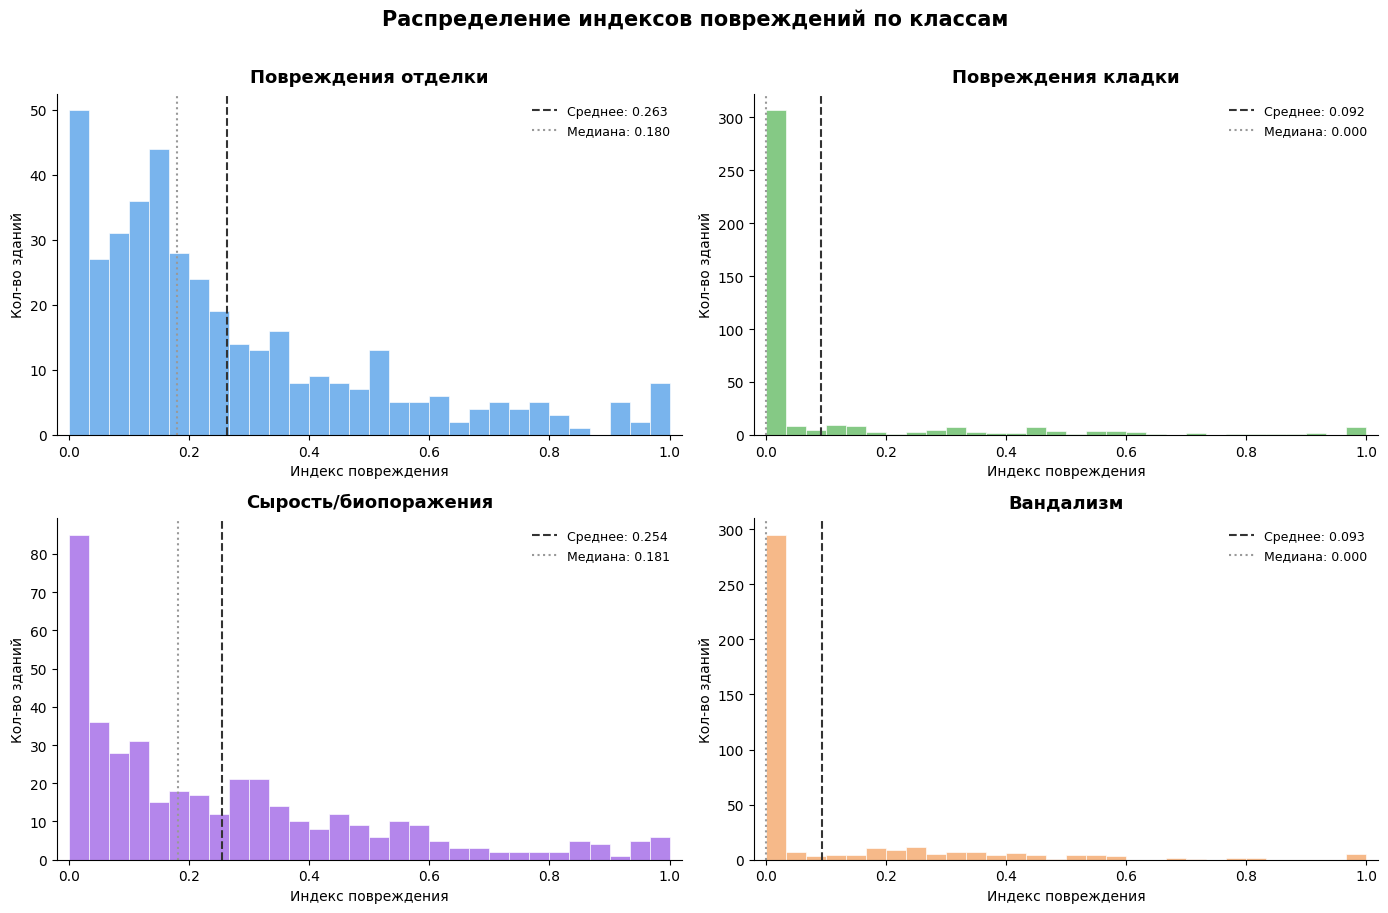

In [15]:
# Распределения индексов
fig, axes = plt.subplots(2, 2, figsize=(14, 9), facecolor='white')
axes = axes.flatten()

for ax, cls, col, label, color in zip(axes, classes, score_cols, class_labels, class_colors):
    data = scores_df[col]
    
    ax.hist(data, bins=30, color=color, alpha=0.75, edgecolor='white', linewidth=0.6)
    ax.axvline(data.mean(),   color='#333333', linestyle='--', linewidth=1.5, label=f'Среднее: {data.mean():.3f}')
    ax.axvline(data.median(), color='#999999', linestyle=':',  linewidth=1.5, label=f'Медиана: {data.median():.3f}')
    
    ax.set_title(label.replace('\n', ' '), fontsize=13, fontweight='bold', pad=8)
    ax.set_xlabel('Индекс повреждения', fontsize=10)
    ax.set_ylabel('Кол-во зданий', fontsize=10)
    ax.legend(fontsize=9, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlim(-0.02, 1.02)

plt.suptitle('Распределение индексов повреждений по классам', 
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

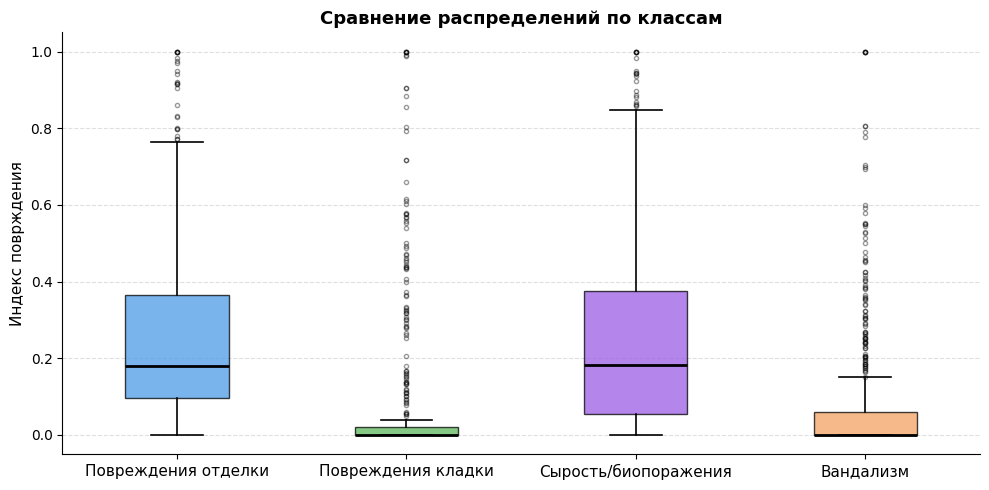

In [16]:
# Ящики с усами
fig, ax = plt.subplots(figsize=(10, 5), facecolor='white')

bp = ax.boxplot(
    [scores_df[col] for col in score_cols],
    patch_artist=True, notch=False,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=3, alpha=0.4)
)
for patch, color in zip(bp['boxes'], class_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_xticks(range(1, 5))
ax.set_xticklabels([l.replace('\n', ' ') for l in class_labels], fontsize=11)
ax.set_ylabel('Индекс поврждения', fontsize=11)
ax.set_title('Сравнение распределений по классам', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

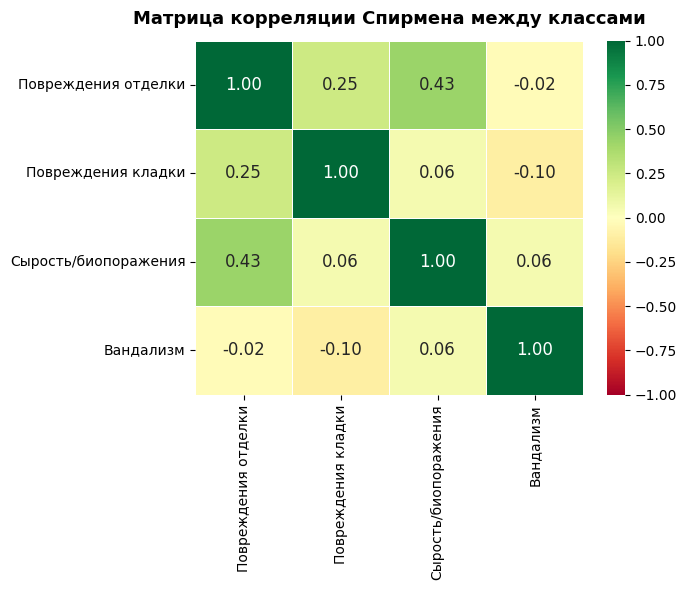

In [17]:
# Матрица корреляций
corr_matrix = scores_df[score_cols].corr(method='spearman')
corr_matrix.index   = [l.replace('\n', ' ') for l in class_labels]
corr_matrix.columns = [l.replace('\n', ' ') for l in class_labels]

fig, ax = plt.subplots(figsize=(7, 6), facecolor='white')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, linewidths=0.5,
            ax=ax, annot_kws={'size': 12})
ax.set_title('Матрица корреляции Спирмена между классами', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('../score_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Топ-10 по каждому классу
for cls, col, label in zip(classes, score_cols, class_labels):
    top10 = scores_df[col].nlargest(10)
    label_clean = label.replace('\n', ' ')
    print(f"{label_clean}:")
    for rank, (name, val) in enumerate(top10.items(), 1):
        print(f"  {rank:2d}. Здание {name:>6s}  →  {val:.3f}")
    print()

Повреждения отделки:
   1. Здание     35  →  1.000
   2. Здание    158  →  1.000
   3. Здание    168  →  1.000
   4. Здание     18  →  1.000
   5. Здание    218  →  1.000
   6. Здание    164  →  0.983
   7. Здание     25  →  0.974
   8. Здание    163  →  0.970
   9. Здание    246  →  0.948
  10. Здание    291  →  0.942

Повреждения кладки:
   1. Здание    113  →  1.000
   2. Здание     35  →  1.000
   3. Здание    235  →  1.000
   4. Здание    200  →  1.000
   5. Здание     36  →  1.000
   6. Здание     21  →  0.991
   7. Здание    101  →  0.988
   8. Здание      5  →  0.906
   9. Здание    224  →  0.904
  10. Здание    263  →  0.885

Сырость/биопоражения:
   1. Здание    160  →  1.000
   2. Здание    269  →  1.000
   3. Здание    255  →  1.000
   4. Здание    238  →  1.000
   5. Здание    203  →  1.000
   6. Здание    363  →  0.984
   7. Здание    237  →  0.949
   8. Здание     93  →  0.945
   9. Здание    268  →  0.944
  10. Здание    362  →  0.942

Вандализм:
   1. Здание    256  → 